<a href="https://colab.research.google.com/github/ajai1996/exit_exam/blob/main/Exit_Exam_Airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [57]:
import numpy as np
import pandas as pd
from google.colab import drive
from datetime import datetime
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

#Load Data

In [3]:
drive.mount('/content/drive')
filepath='/content/drive/MyDrive/DSA ICT/Data/partpdf_1772778618075_partpdf_1763620814447_airbnb.xlsx'
df=pd.read_excel(filepath)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,500,2008-06-26,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
1,500,2008-06-26,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0
2,1039,2008-07-25,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149,100.0
3,1783,2008-08-12,Amazing Also,Manhattan,Apartment,100.0,Entire home/apt,10004.0,1.0,1,9,250,100.0
4,2078,2008-08-15,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,90.0,Private room,11201.0,1.0,1,80,90,94.0


In [13]:
df['Host Since'] = pd.to_datetime(df['Host Since'],errors='coerce')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30475 entries, 0 to 30474
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Host Id                     30475 non-null  int64         
 1   Host Since                  30475 non-null  datetime64[ns]
 2   Name                        30475 non-null  object        
 3   Neighbourhood               30475 non-null  object        
 4   Property Type               30472 non-null  object        
 5   Review Scores Rating (bin)  22155 non-null  float64       
 6   Room Type                   30475 non-null  object        
 7   Zipcode                     30341 non-null  float64       
 8   Beds                        30390 non-null  float64       
 9   Number of Records           30475 non-null  int64         
 10  Number Of Reviews           30475 non-null  int64         
 11  Price                       30475 non-null  int64     

New feature:'Host Tenure'
Host_Tenure= Current Date-Host Since


Hosts who have been on the platform for a longer period are often more experienced in managing listings. They may have better understanding of pricing strategies,more positive reviews and reputation, better maintained properties, higher guest satisfaction.

#Handling Missing Data


In [18]:
df['Review Scores Rating (bin)'].isnull().sum()

np.int64(8320)

In [19]:
df['Review Scores Rating'].isnull().sum()

np.int64(8320)

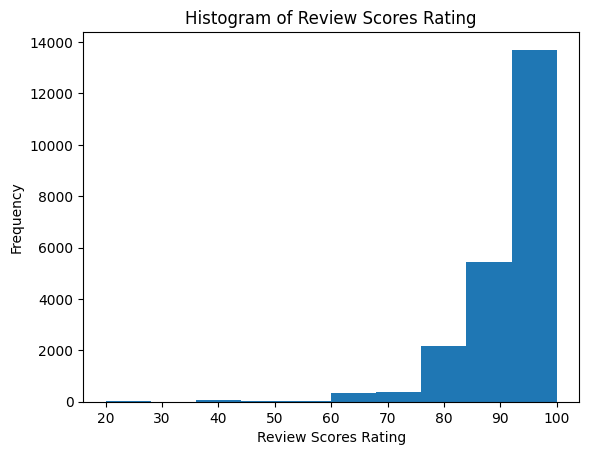

In [25]:
plt.figure()
plt.hist(df['Review Scores Rating'])
plt.title(f'Histogram of Review Scores Rating')
plt.xlabel('Review Scores Rating')
plt.ylabel('Frequency')
plt.show()

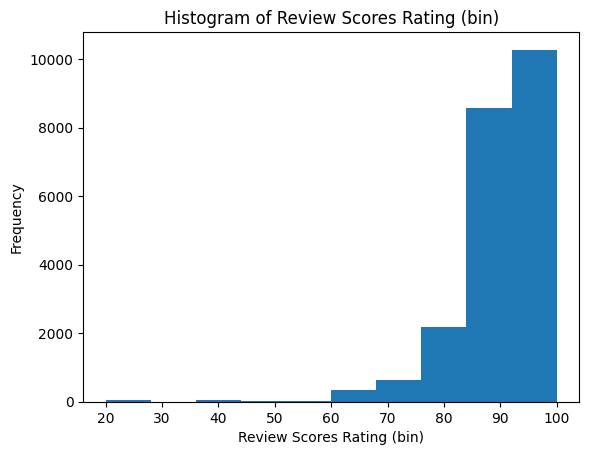

In [26]:
plt.figure()
plt.hist(df['Review Scores Rating (bin)'])
plt.title(f'Histogram of Review Scores Rating (bin)')
plt.xlabel('Review Scores Rating (bin)')
plt.ylabel('Frequency')
plt.show()

In [27]:
df['Review Scores Rating']=df['Review Scores Rating'].fillna(df['Review Scores Rating'].median())
df['Review Scores Rating (bin)']=df['Review Scores Rating (bin)'].fillna(df['Review Scores Rating (bin)'].median())

In [28]:
df[['Review Scores Rating (bin)','Review Scores Rating']].isnull().sum()

,0
Review Scores Rating (bin),0
Review Scores Rating,0


Used Median as the choice of imputation strategy for the Review Scores Rating column. Using median value of the column, I have filled the missing values of the same column because the data in that column is skewed as shown in histogram.

#Advanced Feature Engineering

In [30]:
df1=df.copy()  # df1= with new feature
df2=df.copy()  # df2= without new feature

In [38]:
df1.columns = df1.columns.str.strip().str.lower().str.replace(" ", "_")

In [47]:
df2.columns = df2.columns.str.strip().str.lower().str.replace(" ", "_")

In [39]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30475 entries, 0 to 30474
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   host_id                     30475 non-null  int64         
 1   host_since                  30475 non-null  datetime64[ns]
 2   name                        30475 non-null  object        
 3   neighbourhood               30475 non-null  object        
 4   property_type               30472 non-null  object        
 5   review_scores_rating_(bin)  30475 non-null  float64       
 6   room_type                   30475 non-null  object        
 7   zipcode                     30341 non-null  float64       
 8   beds                        30390 non-null  float64       
 9   number_of_records           30475 non-null  int64         
 10  number_of_reviews           30475 non-null  int64         
 11  price                       30475 non-null  int64     

In [40]:
df1['neighbourhood_roomtype'] = df1['neighbourhood'] + "_" + df1['room_type']

In [41]:
cat_cols = df1.select_dtypes(include=['object']).columns
for col in cat_cols:
  print('Coloumn : ',col)
  print(df1[col].value_counts(dropna=False))
print('Categorical columns:\n',cat_cols)

Coloumn :  name
name
Charming West Village studio           15
HOME AWAY FROM HOME                    12
Private room in Brooklyn               12
Loft Suite @ The Box House Hotel       11
Private Room in WILLIAMSBURG           11
                                       ..
Huge Loft Bed + Rock Climbing Wall      1
Cozy Room with a Hammock!               1
Private Room in Heart of WBurg          1
Park View Apt, 15 Min to Manhattan      1
Great Apt !! 2Bed, 2Bath & Roofdeck     1
Name: count, Length: 29414, dtype: int64
Coloumn :  neighbourhood
neighbourhood
Manhattan        16032
Brooklyn         11673
Queens            2278
Bronx              345
Staten Island      147
Name: count, dtype: int64
Coloumn :  property_type
property_type
Apartment          27099
House               2090
Loft                 753
Bed & Breakfast      180
Townhouse            136
Condominium           94
Other                 47
Dorm                  31
Villa                  8
Boat                   8
Camper/

In [45]:
df1.drop(columns=['host_id','name',],axis=1,inplace=True)

In [48]:
df2.drop(columns=['host_id','name',],axis=1,inplace=True)

In [62]:
# Convert date to tenure
df1['host_tenure_days'] = (pd.Timestamp.today() - df1['host_since']).dt.days

# Drop original date
df1 = df1.drop(columns=['host_since'])

In [64]:
# Convert date to tenure
df2['host_tenure_days'] = (pd.Timestamp.today() - df2['host_since']).dt.days

# Drop original date
df2 = df2.drop(columns=['host_since'])

#Encoding

df1

In [50]:
encode_cols=['neighbourhood','property_type','room_type','neighbourhood_roomtype']
for col in encode_cols:
    le = LabelEncoder()
    df1[col] = le.fit_transform(df1[col])

df2

In [51]:
encode_cols2=['neighbourhood','property_type','room_type']
for col in encode_cols2:
    le = LabelEncoder()
    df2[col] = le.fit_transform(df2[col])

#Train-Test Split

df1

In [65]:
X=df1.drop('price',axis=1)
y=df1['price']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=50)

df2

In [66]:
X2=df2.drop('price',axis=1)
y2=df2['price']
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2,y2,test_size=0.2,random_state=50)

#Scaling

df1

In [68]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

df2

In [69]:
scaler2= StandardScaler()
X_train2=scaler2.fit_transform(X_train2)
X_test2=scaler2.transform(X_test2)

#Modeling

df1

In [70]:
model = RandomForestRegressor(random_state=50)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [71]:
r2_score1 = r2_score(y_test, y_pred)
print(f'Random Forest R2 Score of df1: {r2_score1}')

Random Forest R2 Score of df1: 0.1786987093565161


df2

In [72]:
model2 = RandomForestRegressor(random_state=50)
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

In [73]:
r2_score2 = r2_score(y_test2, y_pred2)
print(f'Random Forest R2 Score of df2: {r2_score2}')

Random Forest R2 Score of df2: 0.17465505217610355


Analytical answer:

Random Forest R2 Score of df1 (with new feature): 0.1786987093565161

Random Forest R2 Score of df2: 0.17465505217610355

Yes the new feature improved the model's performance.



But This model's Accuracy is very low. The r2 score should me close to 1. But here it is 0.17, it is very low.

#Save pickle file of modeling

In [75]:
import pickle
pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))